In [1]:
import pandas as pd
import ast

from collections import Counter, defaultdict
import math
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

In [3]:
train_df["tokens"] = train_df["tokens"].apply(ast.literal_eval)
test_df["tokens"] = test_df["tokens"].apply(ast.literal_eval)

# Building ngrams LM

In [4]:
def build_word_model_with_padding(sentences, n=3):

    model = defaultdict(Counter)

    for sentence in sentences:

        words = [word.lower() for word in sentence]

        padded = ["<s>"] * (n - 1) + words + ["</s>"]


        for i in range(len(padded) - (n - 1)):
            prefix = tuple(padded[i : i + n - 1])
            next_word = padded[i + n - 1]
            model[prefix][next_word] += 1

    return model


In [5]:
def build_ngram_models_per_category(train_df, n=2):
    ngram_models = {}

    categories = train_df["category_10"].unique()

    for category in categories:
        sentences = train_df[train_df["category_10"] == category]["tokens"].tolist()
        model = build_word_model_with_padding(sentences, n=n)

        vocab = set()
        total_ngrams = 0
        for prefix, counter in model.items():
            for word, count in counter.items():
                vocab.add(word)
                total_ngrams += count

        ngram_models[category] = {
            "ngram_counts": model,
            "total_ngrams": total_ngrams,
            "vocab": vocab,
            "vocab_size": len(vocab),
            "n": n
        }

    return ngram_models


In [6]:
unigram_models = build_ngram_models_per_category(train_df, n=1)
bigram_models = build_ngram_models_per_category(train_df, n=2)

In [7]:
trigram_models = build_ngram_models_per_category(train_df, n=3)

In [9]:
bigram_models["SPORTS"] 

{'ngram_counts': defaultdict(collections.Counter,
             {('<s>',): Counter({'the': 179,
                       '<': 114,
                       'watch': 99,
                       'this': 78,
                       'nfl': 70,
                       'us': 52,
                       'lebron': 49,
                       'a': 42,
                       'nba': 34,
                       'how': 33,
                       'heres': 33,
                       'michael': 32,
                       'olympic': 26,
                       'new': 25,
                       'mlb': 24,
                       'tom': 24,
                       'why': 24,
                       'former': 23,
                       'serena': 22,
                       'live': 21,
                       'report': 20,
                       'tiger': 20,
                       'what': 18,
                       'stephen': 18,
                       'tim': 18,
                       'kobe': 18,
                       'e

# calculate the probability 

In [8]:
def ngram_probability(prefix, word, model):
    ngram_counts = model["ngram_counts"]
    vocab_size = model["vocab_size"]

    prefix_counts = ngram_counts.get(prefix, Counter())
    numerator = prefix_counts.get(word, 0) + 1
    denominator = sum(prefix_counts.values()) + vocab_size

    return numerator / denominator


In [9]:
def ngram_log_likelihood(tokens, model):
    n = model["n"]

    # padding
    padded = ["<s>"] * (n - 1) + tokens + ["</s>"]

    log_prob = 0.0

    for i in range(len(padded) - (n - 1)):
        prefix = tuple(padded[i : i + n - 1])
        word = padded[i + n - 1]

        prob = ngram_probability(prefix, word, model)
        log_prob += math.log(prob)

    return log_prob


In [10]:
def ngram_perplexity(tokens, model):
    n = model["n"]
    N = len(tokens) + 1  # + </s>

    log_prob = ngram_log_likelihood(tokens, model)

    return math.exp(-log_prob / N)


In [11]:
def classify_with_perplexity(tokens, ngram_models):
    scores = {}

    for category, model in ngram_models.items():
        scores[category] = ngram_perplexity(tokens, model)

    return min(scores, key=scores.get)


In [19]:
def classify_with_likelihood_and_perplexity(tokens, ngram_models):
    results = {}

    for category, model in ngram_models.items():
        likelihood = ngram_log_likelihood(tokens, model)
        perplexity = ngram_perplexity(tokens, model)

        results[category] = {
            "log_likelihood": likelihood,
            "perplexity": perplexity
        }

    return results


In [20]:
def predict_by_perplexity(results):
    return min(results, key=lambda x: results[x]["perplexity"])
def predict_by_likelihood(results):
    return max(results, key=lambda x: results[x]["log_likelihood"])


In [14]:
sample = test_df.iloc[7]

tokens = sample["tokens"]
true_label = sample["category_10"]

pred = classify_with_perplexity(tokens, bigram_models)

print("Tokens:", tokens)
print("True:", true_label)
print("Pred:", pred)


Tokens: ['would', 'you', 'stay', 'at', 'a', 'hotel', 'without', 'wifi']
True: TRAVEL
Pred: TRAVEL


# Scoring results

In [21]:
y_true = test_df["category_10"].tolist()

In [27]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, unigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"unigram LM (Perplexity) Accuracy: {accuracy:.4f}")


unigram LM (Perplexity) Accuracy: 0.4635


In [23]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, unigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"Unigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"Unigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


Unigram LM Accuracy (Perplexity): 0.4635
Unigram LM Accuracy (Log-Likelihood): 0.4635


In [ ]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, bigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"Bigram LM (Perplexity) Accuracy: {accuracy:.4f}")


In [25]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, bigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"bigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"bigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


bigram LM Accuracy (Perplexity): 0.3498
bigram LM Accuracy (Log-Likelihood): 0.3498


In [ ]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, trigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"trigram LM (Perplexity) Accuracy: {accuracy:.4f}")


trigram LM (Perplexity) Accuracy: 0.1458


In [26]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, trigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"trigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"trigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


trigram LM Accuracy (Perplexity): 0.1458
trigram LM Accuracy (Log-Likelihood): 0.1458


In [28]:
categories = list(bigram_models.keys())

cm = confusion_matrix(y_true, y_pred, labels=categories)
cm_df = pd.DataFrame(cm, index=categories, columns=categories)

cm_df


,POLITICS,OTHER,STYLE & BEAUTY,WELLNESS,TRAVEL,ENTERTAINMENT,SPORTS,FOOD & DRINK,QUEER VOICES,BUSINESS
POLITICS,5027,182,41,80,93,104,286,130,448,730
OTHER,1590,2888,988,2332,1220,1215,1589,1833,2664,2711
STYLE & BEAUTY,7,13,1543,79,43,31,20,107,48,72
WELLNESS,28,82,38,2411,134,39,91,352,143,271
TRAVEL,11,27,31,33,1579,11,38,123,49,78
ENTERTAINMENT,110,59,211,59,81,2121,224,94,346,168
SPORTS,10,9,10,13,12,20,864,14,36,27
FOOD & DRINK,1,11,6,28,39,4,13,1128,18,20
QUEER VOICES,31,20,10,44,17,38,32,20,1034,23
BUSINESS,66,22,8,86,45,14,33,54,43,827


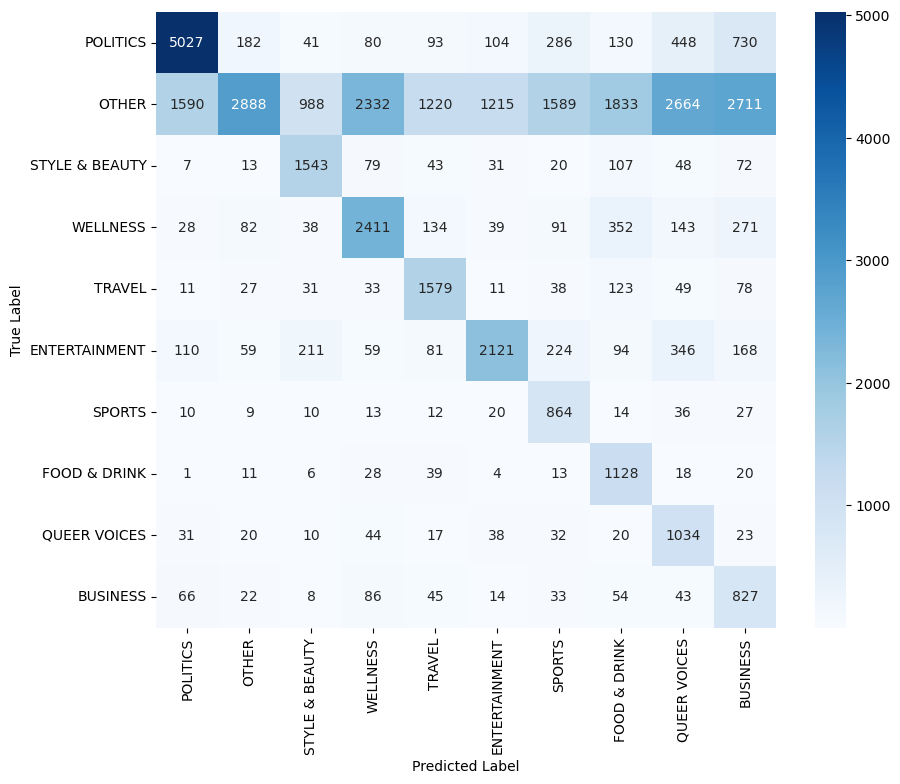

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()